In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# Project directory
PROJECT_DIR = '/content/drive/MyDrive/Brain_MRI_Project'

# Dataset and model directories
DATA_DIR = os.path.join(PROJECT_DIR, 'MRI_Images')
MODEL_DIR = os.path.join(PROJECT_DIR, 'models')

# Create models folder if it doesn't exist
os.makedirs(MODEL_DIR, exist_ok=True)

print("Project Directory:", PROJECT_DIR)
print("Dataset Directory:", DATA_DIR)
print("Model Directory:", MODEL_DIR)

Mounted at /content/drive
Project Directory: /content/drive/MyDrive/Brain_MRI_Project
Dataset Directory: /content/drive/MyDrive/Brain_MRI_Project/MRI_Images
Model Directory: /content/drive/MyDrive/Brain_MRI_Project/models


In [ ]:
DATA_DIR = "/content/MRI_Images"

In [ ]:
import shutil
import os

source = "/content/drive/MyDrive/Brain_MRI_Project/MRI_Images"
destination = "/content/MRI_Images"

if not os.path.exists(destination):
    print("Copying dataset to local storage...")
    shutil.copytree(source, destination)
    print("Done!")
else:
    print("Dataset already copied.")

Copying dataset to local storage...
Done!


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import os
import time
import wandb
import random
import numpy as np

# ==========================================
# 0. CONFIGURATION – EDIT THESE TWO LINES
# ==========================================
MODEL_CHOICE = "resnet50"   # Options: "resnet50" or "efficientnet_b2"         # <-- set your data root (e.g., /content/data)
MODEL_DIR = "/content/MODEL_WEIGHTS"      # <-- folder to save best model
os.makedirs(MODEL_DIR, exist_ok=True)

# Hyperparameters (IDENTICAL for fair comparison)
SEED = 42                   # FIXED SEED – Ensures same train/val split for both models
BATCH_SIZE = 32
NUM_EPOCHS = 15
BASE_LR = 1e-3              # Learning rate for the new classifier head
BACKBONE_LR = 1e-5          # Much lower LR for fine‑tuning the pre-trained backbone
WEIGHT_DECAY = 1e-4

# ==========================================
# 1. SET SEED FOR REPRODUCIBILITY (CRITICAL)
# ==========================================
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make CuDNN deterministic (slows down slightly, but guarantees identical results)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"🔒 Reproducibility: Seed set to {SEED}")

# ==========================================
# 2. DATA LOADING (IDENTICAL for both models)
# ==========================================
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_path = os.path.join(DATA_DIR, 'Training')
test_path = os.path.join(DATA_DIR, 'Testing')

print(f"📂 Loading training data from: {train_path}")
print(f"📂 Loading testing data from: {test_path}")

train_full_dataset = datasets.ImageFolder(root=train_path, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_path, transform=val_transforms)

# ---- SPLIT WITH FIXED GENERATOR ----
train_size = int(0.8 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size

# This is the MAGIC line that guarantees the EXACT SAME split for both runs
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    train_full_dataset,
    [train_size, val_size],
    generator=generator
)

# Apply validation transforms (no augmentation) to the validation subset
val_dataset.dataset.transform = val_transforms

# ---- DataLoaders ----
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.dataset.classes
print(f"\n✅ Data loaded successfully with FIXED SPLIT!")
print(f"   Classes: {class_names}")
print(f"   Training samples: {len(train_dataset)}")
print(f"   Validation samples: {len(val_dataset)}")
print(f"   Testing samples: {len(test_dataset)}")

# ==========================================
# 3. MODEL DEFINITION (with FINE‑TUNING)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🚀 Using device: {device}")

# ---- Build the chosen model ----
if MODEL_CHOICE == "resnet50":
    print("🔄 Loading ResNet‑50 for FINE‑TUNING")
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    # Freeze EVERYTHING first
    for param in model.parameters():
        param.requires_grad = False

    # UNFREEZE the last 2 residual blocks (layer3 and layer4)
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.layer3.parameters():
        param.requires_grad = True

    # Replace the final FC layer (always trainable)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(class_names))

    # Separate parameter groups for differential LR
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            if 'fc' in name:
                head_params.append(param)
            else:
                backbone_params.append(param)

elif MODEL_CHOICE == "efficientnet_b2":
    print("🔄 Loading EfficientNet‑B2 for FINE‑TUNING")
    model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

    # Freeze EVERYTHING first
    for param in model.parameters():
        param.requires_grad = False

    # UNFREEZE the last 3 blocks (blocks 5, 6, and 7)
    for param in model.features[-3:].parameters():
        param.requires_grad = True

    # Replace the classifier head (always trainable)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, len(class_names))

    # Separate parameter groups for differential LR
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            if 'classifier' in name:
                head_params.append(param)
            else:
                backbone_params.append(param)

else:
    raise ValueError(f"Unknown MODEL_CHOICE: {MODEL_CHOICE}")

model = model.to(device)

print(f"✅ Model ready for FINE‑TUNING!")
print(f"   🔹 Trainable backbone parameters: {len(backbone_params)} groups")
print(f"   🔹 Trainable head parameters: {len(head_params)} groups")

# ==========================================
# 4. TRAINING SETUP (Differential LR)
# ==========================================
wandb.init(
    project="brain-mri-classification",
    name=f"{MODEL_CHOICE}-finetuned-seed{SEED}",   # e.g., "resnet50-finetuned-seed42"
    config={
        "seed": SEED,
        "model": MODEL_CHOICE,
        "learning_rate_backbone": BACKBONE_LR,
        "learning_rate_head": BASE_LR,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "weight_decay": WEIGHT_DECAY,
        "finetuned_layers": "layer3+layer4" if MODEL_CHOICE == "resnet50" else "last_3_blocks"
    }
)

criterion = nn.CrossEntropyLoss()

# DIFFERENTIAL learning rate:
# - Backbone gets a tiny LR (1e-5) so it adapts slowly without forgetting ImageNet features.
# - New head gets a normal LR (1e-3) so it learns fast.
optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': BACKBONE_LR},
    {'params': head_params, 'lr': BASE_LR}
], weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# ==========================================
# 5. TRAINING LOOP (Identical for both)
# ==========================================
def train_model(model, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS):
    since = time.time()
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 30)

        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_epoch_acc = val_corrects.double() / len(val_loader.dataset)

        scheduler.step(val_epoch_loss)

        print(f'Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')
        print(f'Val Loss: {val_epoch_loss:.4f} | Acc: {val_epoch_acc:.4f}')

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": epoch_loss,
            "train_acc": epoch_acc,
            "val_loss": val_epoch_loss,
            "val_acc": val_epoch_acc
        })

        # Save best model based on validation loss
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            torch.save(model.state_dict(), os.path.join(MODEL_DIR, f'best_model_{MODEL_CHOICE}.pth'))
            print(f"💾 Saved best {MODEL_CHOICE} model!")

    time_elapsed = time.time() - since
    print(f'\n⏱️ Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

# ==========================================
# 6. RUN TRAINING
# ==========================================
train_model(model, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS)

# ==========================================
# 7. FINAL TEST EVALUATION (Same Test Set)
# ==========================================
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, f'best_model_{MODEL_CHOICE}.pth')))
model.eval()

print("\n" + "="*50)
print(f"🧪 FINAL EVALUATION ON TEST SET ({MODEL_CHOICE})")
print("="*50)

test_corrects = 0
total_samples = 0
class_corrects = [0] * len(class_names)
class_totals = [0] * len(class_names)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        test_corrects += torch.sum(preds == labels.data)
        total_samples += labels.size(0)

        for i in range(len(labels)):
            if preds[i] == labels[i]:
                class_corrects[labels[i]] += 1
            class_totals[labels[i]] += 1

test_acc = test_corrects.double() / total_samples
print(f"\n📊 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"📊 Correct: {test_corrects} / {total_samples}")

print("\n Per-Class Accuracy:")
for i, class_name in enumerate(class_names):
    if class_totals[i] > 0:
        class_acc = class_corrects[i] / class_totals[i]
        print(f"  {class_name}: {class_acc:.4f} ({class_corrects[i]}/{class_totals[i]})")

wandb.log({
    "test_accuracy": test_acc,
    "test_correct": test_corrects,
    "test_total": total_samples
})

wandb.finish()

print(f"\n✅ All done! Model saved to: {os.path.join(MODEL_DIR, f'best_model_{MODEL_CHOICE}.pth')}")
print("🎉 Ready for deployment!")

🔒 Reproducibility: Seed set to 42
📂 Loading training data from: /content/MRI_Images/Training
📂 Loading testing data from: /content/MRI_Images/Testing

✅ Data loaded successfully with FIXED SPLIT!
   Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
   Training samples: 4570
   Validation samples: 1143
   Testing samples: 1311

🚀 Using device: cuda
🔄 Loading ResNet‑50 for FINE‑TUNING
✅ Model ready for FINE‑TUNING!
   🔹 Trainable backbone parameters: 87 groups
   🔹 Trainable head parameters: 2 groups



Epoch 1/15
------------------------------
Train Loss: 0.5153 | Acc: 0.8267
Val Loss: 0.2618 | Acc: 0.9108
💾 Saved best resnet50 model!

Epoch 2/15
------------------------------
Train Loss: 0.1947 | Acc: 0.9280
Val Loss: 0.1780 | Acc: 0.9388
💾 Saved best resnet50 model!

Epoch 3/15
------------------------------
Train Loss: 0.0935 | Acc: 0.9687
Val Loss: 0.1577 | Acc: 0.9466
💾 Saved best resnet50 model!

Epoch 4/15
------------------------------
Train Loss: 0.0552 | Acc: 0.9821
Val Loss: 0.1265 | Acc: 0.9545
💾 Saved best resnet50 model!

Epoch 5/15
------------------------------
Train Loss: 0.0318 | Acc: 0.9915
Val Loss: 0.1287 | Acc: 0.9545

Epoch 6/15
------------------------------
Train Loss: 0.0186 | Acc: 0.9956
Val Loss: 0.1240 | Acc: 0.9598
💾 Saved best resnet50 model!

Epoch 7/15
------------------------------
Train Loss: 0.0155 | Acc: 0.9958
Val Loss: 0.1219 | Acc: 0.9598
💾 Saved best resnet50 model!

Epoch 8/15
------------------------------
Train Loss: 0.0127 | Acc: 0.9974
V

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_accuracy,▁
test_correct,▁
test_total,▁
train_acc,▁▅▇▇███████████
train_loss,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▅▆▆▇▇▇▆▇███▇▇
val_loss,█▄▃▂▂▁▁▁▃▂▂▁▁▂▂
epoch,15
test_accuracy,0.955
test_correct,1252



✅ All done! Model saved to: /content/MODEL_WEIGHTS/best_model_resnet50.pth
🎉 Ready for deployment!


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import os
import time
import wandb
import random
import numpy as np

# ==========================================
# 0. CONFIGURATION – EDIT THESE TWO LINES
# ==========================================
MODEL_CHOICE = "efficientnet_b2"   # Options: "resnet50" or "efficientnet_b2"         # <-- set your data root (e.g., /content/data)
MODEL_DIR = "/content/MODEL_WEIGHTS_2"      # <-- folder to save best model
os.makedirs(MODEL_DIR, exist_ok=True)

# Hyperparameters (IDENTICAL for fair comparison)
SEED = 42                   # FIXED SEED – Ensures same train/val split for both models
BATCH_SIZE = 32
NUM_EPOCHS = 15
BASE_LR = 1e-3              # Learning rate for the new classifier head
BACKBONE_LR = 1e-5          # Much lower LR for fine‑tuning the pre-trained backbone
WEIGHT_DECAY = 1e-4

# ==========================================
# 1. SET SEED FOR REPRODUCIBILITY (CRITICAL)
# ==========================================
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make CuDNN deterministic (slows down slightly, but guarantees identical results)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"🔒 Reproducibility: Seed set to {SEED}")

# ==========================================
# 2. DATA LOADING (IDENTICAL for both models)
# ==========================================
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_path = os.path.join(DATA_DIR, 'Training')
test_path = os.path.join(DATA_DIR, 'Testing')

print(f"📂 Loading training data from: {train_path}")
print(f"📂 Loading testing data from: {test_path}")

train_full_dataset = datasets.ImageFolder(root=train_path, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_path, transform=val_transforms)

# ---- SPLIT WITH FIXED GENERATOR ----
train_size = int(0.8 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size

# This is the MAGIC line that guarantees the EXACT SAME split for both runs
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    train_full_dataset,
    [train_size, val_size],
    generator=generator
)

# Apply validation transforms (no augmentation) to the validation subset
val_dataset.dataset.transform = val_transforms

# ---- DataLoaders ----
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.dataset.classes
print(f"\n✅ Data loaded successfully with FIXED SPLIT!")
print(f"   Classes: {class_names}")
print(f"   Training samples: {len(train_dataset)}")
print(f"   Validation samples: {len(val_dataset)}")
print(f"   Testing samples: {len(test_dataset)}")

# ==========================================
# 3. MODEL DEFINITION (with FINE‑TUNING)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🚀 Using device: {device}")

# ---- Build the chosen model ----
if MODEL_CHOICE == "resnet50":
    print("🔄 Loading ResNet‑50 for FINE‑TUNING")
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    # Freeze EVERYTHING first
    for param in model.parameters():
        param.requires_grad = False

    # UNFREEZE the last 2 residual blocks (layer3 and layer4)
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.layer3.parameters():
        param.requires_grad = True

    # Replace the final FC layer (always trainable)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(class_names))

    # Separate parameter groups for differential LR
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            if 'fc' in name:
                head_params.append(param)
            else:
                backbone_params.append(param)

elif MODEL_CHOICE == "efficientnet_b2":
    print("🔄 Loading EfficientNet‑B2 for FINE‑TUNING")
    model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

    # Freeze EVERYTHING first
    for param in model.parameters():
        param.requires_grad = False

    # UNFREEZE the last 3 blocks (blocks 5, 6, and 7)
    for param in model.features[-3:].parameters():
        param.requires_grad = True

    # Replace the classifier head (always trainable)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, len(class_names))

    # Separate parameter groups for differential LR
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            if 'classifier' in name:
                head_params.append(param)
            else:
                backbone_params.append(param)

else:
    raise ValueError(f"Unknown MODEL_CHOICE: {MODEL_CHOICE}")

model = model.to(device)

print(f"✅ Model ready for FINE‑TUNING!")
print(f"   🔹 Trainable backbone parameters: {len(backbone_params)} groups")
print(f"   🔹 Trainable head parameters: {len(head_params)} groups")

# ==========================================
# 4. TRAINING SETUP (Differential LR)
# ==========================================
wandb.init(
    project="brain-mri-classification",
    name=f"{MODEL_CHOICE}-finetuned-seed{SEED}",   # e.g., "resnet50-finetuned-seed42"
    config={
        "seed": SEED,
        "model": MODEL_CHOICE,
        "learning_rate_backbone": BACKBONE_LR,
        "learning_rate_head": BASE_LR,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "weight_decay": WEIGHT_DECAY,
        "finetuned_layers": "layer3+layer4" if MODEL_CHOICE == "resnet50" else "last_3_blocks"
    }
)

criterion = nn.CrossEntropyLoss()

# DIFFERENTIAL learning rate:
# - Backbone gets a tiny LR (1e-5) so it adapts slowly without forgetting ImageNet features.
# - New head gets a normal LR (1e-3) so it learns fast.
optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': BACKBONE_LR},
    {'params': head_params, 'lr': BASE_LR}
], weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# ==========================================
# 5. TRAINING LOOP (Identical for both)
# ==========================================
def train_model(model, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS):
    since = time.time()
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 30)

        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_epoch_acc = val_corrects.double() / len(val_loader.dataset)

        scheduler.step(val_epoch_loss)

        print(f'Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')
        print(f'Val Loss: {val_epoch_loss:.4f} | Acc: {val_epoch_acc:.4f}')

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": epoch_loss,
            "train_acc": epoch_acc,
            "val_loss": val_epoch_loss,
            "val_acc": val_epoch_acc
        })

        # Save best model based on validation loss
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            torch.save(model.state_dict(), os.path.join(MODEL_DIR, f'best_model_{MODEL_CHOICE}.pth'))
            print(f"💾 Saved best {MODEL_CHOICE} model!")

    time_elapsed = time.time() - since
    print(f'\n⏱️ Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')

# ==========================================
# 6. RUN TRAINING
# ==========================================
train_model(model, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS)

# ==========================================
# 7. FINAL TEST EVALUATION (Same Test Set)
# ==========================================
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, f'best_model_{MODEL_CHOICE}.pth')))
model.eval()

print("\n" + "="*50)
print(f"🧪 FINAL EVALUATION ON TEST SET ({MODEL_CHOICE})")
print("="*50)

test_corrects = 0
total_samples = 0
class_corrects = [0] * len(class_names)
class_totals = [0] * len(class_names)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        test_corrects += torch.sum(preds == labels.data)
        total_samples += labels.size(0)

        for i in range(len(labels)):
            if preds[i] == labels[i]:
                class_corrects[labels[i]] += 1
            class_totals[labels[i]] += 1

test_acc = test_corrects.double() / total_samples
print(f"\n📊 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"📊 Correct: {test_corrects} / {total_samples}")

print("\n Per-Class Accuracy:")
for i, class_name in enumerate(class_names):
    if class_totals[i] > 0:
        class_acc = class_corrects[i] / class_totals[i]
        print(f"  {class_name}: {class_acc:.4f} ({class_corrects[i]}/{class_totals[i]})")

wandb.log({
    "test_accuracy": test_acc,
    "test_correct": test_corrects,
    "test_total": total_samples
})

wandb.finish()

print(f"\n✅ All done! Model saved to: {os.path.join(MODEL_DIR, f'best_model_{MODEL_CHOICE}.pth')}")
print("🎉 Ready for deployment!")

🔒 Reproducibility: Seed set to 42
📂 Loading training data from: /content/MRI_Images/Training
📂 Loading testing data from: /content/MRI_Images/Testing

✅ Data loaded successfully with FIXED SPLIT!
   Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
   Training samples: 4570
   Validation samples: 1143
   Testing samples: 1311

🚀 Using device: cuda
🔄 Loading EfficientNet‑B2 for FINE‑TUNING
Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 162MB/s]


✅ Model ready for FINE‑TUNING!
   🔹 Trainable backbone parameters: 94 groups
   🔹 Trainable head parameters: 2 groups



Epoch 1/15
------------------------------
Train Loss: 0.5809 | Acc: 0.8098
Val Loss: 0.3030 | Acc: 0.8941
💾 Saved best efficientnet_b2 model!

Epoch 2/15
------------------------------
Train Loss: 0.3041 | Acc: 0.8919
Val Loss: 0.2195 | Acc: 0.9248
💾 Saved best efficientnet_b2 model!

Epoch 3/15
------------------------------
Train Loss: 0.2294 | Acc: 0.9166
Val Loss: 0.1782 | Acc: 0.9396
💾 Saved best efficientnet_b2 model!

Epoch 4/15
------------------------------
Train Loss: 0.1954 | Acc: 0.9313
Val Loss: 0.1527 | Acc: 0.9493
💾 Saved best efficientnet_b2 model!

Epoch 5/15
------------------------------
Train Loss: 0.1632 | Acc: 0.9381
Val Loss: 0.1344 | Acc: 0.9519
💾 Saved best efficientnet_b2 model!

Epoch 6/15
------------------------------
Train Loss: 0.1349 | Acc: 0.9503
Val Loss: 0.1172 | Acc: 0.9563
💾 Saved best efficientnet_b2 model!

Epoch 7/15
------------------------------
Train Loss: 0.1198 | Acc: 0.9556
Val Loss: 0.1022 | Acc: 0.9633
💾 Saved best efficientnet_b2 model!

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_accuracy,▁
test_correct,▁
test_total,▁
train_acc,▁▄▅▆▆▇▇▇▇██████
train_loss,█▄▃▃▃▂▂▂▂▁▁▁▁▁▁
val_acc,▁▄▅▆▆▆▇▇▇▇██▇▇█
val_loss,█▅▄▃▃▂▂▂▂▂▁▁▁▁▁
epoch,15
test_accuracy,0.97483
test_correct,1278



✅ All done! Model saved to: /content/MODEL_WEIGHTS_2/best_model_efficientnet_b2.pth
🎉 Ready for deployment!


In [ ]:
MODEL_DIR = "/content/drive/MyDrive/Brain_MRI_Project/models"

In [ ]:
torch.save(
    model.state_dict(),
    os.path.join(MODEL_DIR, f'best_model_{MODEL_CHOICE}.pth')
)

In [ ]:
import os
os.makedirs("/content/drive/MyDrive/Brain_MRI_Models", exist_ok=True)

In [ ]:
import shutil

shutil.copy(
    "/content/MODEL_WEIGHTS/best_model_resnet50.pth",
    "/content/drive/MyDrive/Brain_MRI_Models/best_model_resnet50.pth"
)

'/content/drive/MyDrive/Brain_MRI_Models/best_model_resnet50.pth'

In [ ]:
shutil.copy(
    "/content/MODEL_WEIGHTS_2/best_model_efficientnet_b2.pth",
    "/content/drive/MyDrive/Brain_MRI_Models/best_model_efficientnet_b2.pth"
)

'/content/drive/MyDrive/Brain_MRI_Models/best_model_efficientnet_b2.pth'

## Hyperparameter Tuning using Optuna


In [ ]:
!pip install Optuna plotly kaleido wandb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.4 MB/s eta 0:00:00


In [ ]:
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

In [ ]:
import wandb

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: dtan12356 (dtan12356-gati-shakti-vishwavidyalaya) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

[I 2026-07-19 18:40:27,797] A new study created in memory with name: efficientnet_b2_hpt


🚀 Starting Optuna Hyperparameter Tuning...
   Trials: 10
   Max Epochs per trial: 3
   Input Size: 260x260
   Each trial will be logged as a separate W&B run (grouped under a sweep).


epoch,▁▅█
train_acc,▁▆█
train_loss,█▃▁
val_acc,▁▃█
val_loss,█▃▁
epoch,2
train_acc,0.92626
train_loss,0.20765
val_acc,0.93963
val_loss,0.15635


best_val_loss,▁
epoch,▁▅█
train_acc,▁▆█
train_loss,█▃▁
val_acc,▁▁█
val_loss,█▅▁
best_val_loss,0.19152
epoch,2
train_acc,0.89059
train_loss,0.31054
val_acc,0.92476


[I 2026-07-19 18:42:20,394] Trial 0 finished with value: 0.19152210260417935 and parameters: {'backbone_lr': 5.611516415334504e-06, 'head_lr': 0.007969454818643935, 'weight_decay': 0.000291063591313307, 'batch_size': 32, 'unfreeze_blocks': 2, 'scheduler_patience': 2}. Best is trial 0 with value: 0.19152210260417935.


...

[I 2026-07-19 18:57:47,898] Trial 8 finished with value: 0.45686082204287237 and parameters: {'backbone_lr': 1.5030900645056814e-06, 'head_lr': 0.0002465844721448739, 'weight_decay': 1.2315571723666024e-05, 'batch_size': 64, 'unfreeze_blocks': 2, 'scheduler_patience': 5}. Best is trial 1 with value: 0.07248391418971206.


best_val_loss,▁
epoch,▁▅█
train_acc,▁▇█
train_loss,█▃▁
val_acc,▁▅█
val_loss,█▃▁
best_val_loss,0.33364
epoch,2
train_acc,0.87549
train_loss,0.41029
val_acc,0.88451


[I 2026-07-19 18:59:36,596] Trial 9 finished with value: 0.3336420918595655 and parameters: {'backbone_lr': 5.170191786366997e-06, 'head_lr': 0.0003646439558980723, 'weight_decay': 0.00012172847081122418, 'batch_size': 64, 'unfreeze_blocks': 2, 'scheduler_patience': 5}. Best is trial 1 with value: 0.07248391418971206.



💾 Saving Optuna study...
✅ Study saved to: /content/MODEL_WEIGHTS/optuna_study.pkl

🏆 Best Trial Results:
   Best Validation Loss: 0.0725

🔬 Best Hyperparameters:
   backbone_lr: 5.39948440978744e-05
   head_lr: 0.0015930522616241021
   weight_decay: 0.0002607024758370766
   batch_size: 64
   unfreeze_blocks: 4
   scheduler_patience: 2


📊 Generating Optuna plots...

🔄 RETRAINING FINAL MODEL ON FULL DATA (15 Epochs)
Epoch 1/15 | Train Loss: 0.4060 | Val Loss: 0.1505 | Val Acc: 0.9493
   💾 Saved best model!
Epoch 2/15 | Train Loss: 0.1276 | Val Loss: 0.0875 | Val Acc: 0.9773
   💾 Saved best model!
Epoch 3/15 | Train Loss: 0.0631 | Val Loss: 0.0643 | Val Acc: 0.9755
   💾 Saved best model!
Epoch 4/15 | Train Loss: 0.0338 | Val Loss: 0.0625 | Val Acc: 0.9790
   💾 Saved best model!
Epoch 5/15 | Train Loss: 0.0244 | Val Loss: 0.0617 | Val Acc: 0.9825
   💾 Saved best model!
Epoch 6/15 | Train Loss: 0.0168 | Val Loss: 0.0557 | Val Acc: 0.9825
   💾 Saved best model!
Epoch 7/15 | Train Loss: 0.0131 | Val Loss: 0.0538 | Val Acc: 0.9878
   💾 Saved best model!
Epoch 8/15 | Train Loss: 0.0174 | Val Loss: 0.0757 | Val Acc: 0.9843
Epoch 9/15 | Train Loss: 0.0084 | Val Loss: 0.0555 | Val Acc: 0.9825
Epoch 10/15 | Train Loss: 0.0108 | Val Loss: 0.0446 | Val Acc: 0.9895
   💾 Saved best model!
Epoch 11/15 | Train Loss: 0.0078 | Val Loss: 

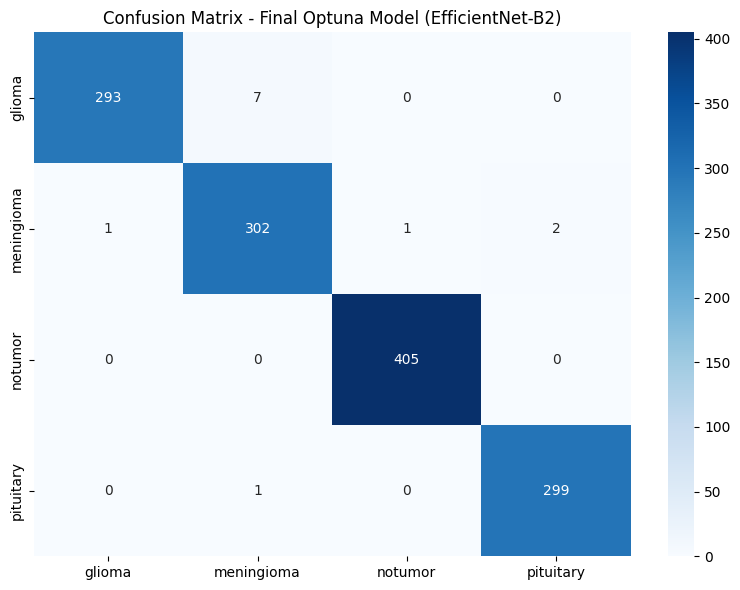

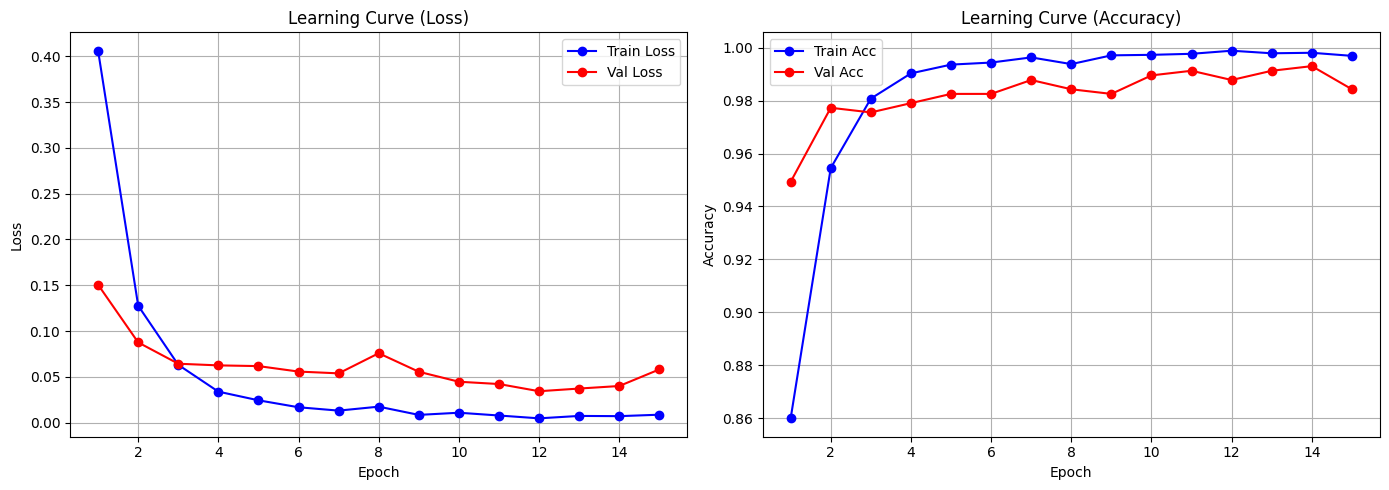

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
final_test_accuracy,▁
final_test_correct,▁
final_test_total,▁
final_train_acc,▁▆▇████████████
final_train_loss,█▃▂▂▁▁▁▁▁▁▁▁▁▁▁
final_val_acc,▁▅▅▆▆▆▇▇▆▇█▇██▇
final_val_loss,█▄▃▃▃▂▂▃▂▂▁▁▁▁▂
test_f1_glioma,▁
test_f1_meningioma,▁
+10,...



✅ ALL DONE! EVERYTHING STORED!

📁 Local files saved to: /content/MODEL_WEIGHTS
   - best_efficientnet_optuna.pth (Model weights)
   - optuna_study.pkl (Full Optuna study object)
   - confusion_matrix_optuna_final.png
   - final_learning_curve.png
   - project_summary.json

📡 W&B Dashboard:
   - 20 individual trial runs (grouped under a sweep)
   - 1 summary run with all final metrics & plots

🎉 Your Resume is now packed with senior-level MLOps practices!


In [ ]:
# ==========================================
# STEP 2: Imports
# ==========================================
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import os
import time
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import random
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import plotly.express as px
import plotly.graph_objects as go
import optuna.visualization as vis
import wandb
import json
import joblib  # NEW: For saving the Optuna study
import pandas as pd

# ==========================================
# STEP 3: Fixed Config
# ==========================================
DATA_DIR = "/content/MRI_Images"    # UPDATE THIS
MODEL_DIR = "/content/MODEL_WEIGHTS"
os.makedirs(MODEL_DIR, exist_ok=True)

SEED = 42
NUM_EPOCHS = 3          # Max epochs per trial
NUM_TRIALS = 10        # Number of Optuna trials
PROJECT_NAME = "brain-mri-classification"
WANDB_ENTITY = "dtan12356-gati-shakti-vishwavidyalaya"     # Set to your W&B username
SWEEP_ID = f"optuna-sweep-{int(time.time())}"  # Group ID for all trial runs

# ==========================================
# STEP 4: Set Seed
# ==========================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ==========================================
# STEP 5: Data Loading (UPGRADED to 260x260)
# ==========================================
# EfficientNet-B2 native size is 260x260 (or 288x288, but 260 is standard and memory-safe)
INPUT_SIZE = 260

train_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),  # UPDATED: 260x260
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),  # UPDATED: 260x260
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_data_loaders(batch_size, split_ratio=0.8):
    train_path = os.path.join(DATA_DIR, 'Training')
    test_path = os.path.join(DATA_DIR, 'Testing')

    train_full_dataset = datasets.ImageFolder(root=train_path, transform=train_transforms)
    test_dataset = datasets.ImageFolder(root=test_path, transform=val_transforms)

    train_size = int(split_ratio * len(train_full_dataset))
    val_size = len(train_full_dataset) - train_size
    generator = torch.Generator().manual_seed(SEED)
    train_dataset, val_dataset = random_split(
        train_full_dataset, [train_size, val_size], generator=generator
    )
    val_dataset.dataset.transform = val_transforms

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader, test_loader, train_full_dataset.classes

# ==========================================
# STEP 6: Model Builder
# ==========================================
def build_efficientnet(num_classes, unfreeze_blocks):
    model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False

    for block in model.features[-unfreeze_blocks:]:
        for param in block.parameters():
            param.requires_grad = True

    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, num_classes)

    return model

# ==========================================
# STEP 7: Training Utilities
# ==========================================
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)
    return epoch_loss, epoch_acc

def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = running_corrects.double() / len(val_loader.dataset)
    return epoch_loss, epoch_acc

# ==========================================
# STEP 8: OPTUNA OBJECTIVE (WITH INDIVIDUAL W&B TRIAL LOGGING)
# ==========================================
def objective(trial):
    # --- Suggest hyperparameters ---
    backbone_lr = trial.suggest_float('backbone_lr', 1e-6, 1e-4, log=True)
    head_lr = trial.suggest_float('head_lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    unfreeze_blocks = trial.suggest_int('unfreeze_blocks', 2, 4)
    scheduler_patience = trial.suggest_int('scheduler_patience', 2, 5)

    set_seed(SEED + trial.number)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_loader, val_loader, test_loader, class_names = get_data_loaders(batch_size)
    num_classes = len(class_names)

    # --- Build model ---
    model = build_efficientnet(num_classes, unfreeze_blocks)
    model = model.to(device)

    # --- Initialize W&B for THIS TRIAL (NEW!) ---
    wandb.init(
        project=PROJECT_NAME,
        entity=WANDB_ENTITY,
        group=SWEEP_ID,  # Groups all trials under one parent
        name=f"trial_{trial.number}",
        config={
            "trial_number": trial.number,
            **trial.params  # Log all hyperparameters for this specific trial
        },
        reinit=True  # Allows multiple inits in one script
    )

    # --- Log model architecture & gradients (NEW!) ---
    wandb.watch(model, log="all", log_freq=100)

    # --- Optimizer ---
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if param.requires_grad:
            if 'classifier' in name:
                head_params.append(param)
            else:
                backbone_params.append(param)

    optimizer = torch.optim.AdamW([
        {'params': backbone_params, 'lr': backbone_lr},
        {'params': head_params, 'lr': head_lr}
    ], weight_decay=weight_decay)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.1, patience=scheduler_patience
    )
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float('inf')

    # --- Training loop ---
    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        # Log to W&B per epoch (for THIS trial)
        wandb.log({
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "epoch": epoch
        })

        # Optuna reporting & pruning
        trial.report(val_loss, epoch)
        if trial.should_prune():
            wandb.log({"pruned": True})
            wandb.finish()
            raise optuna.TrialPruned()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # Save best model within this trial
            torch.save(model.state_dict(), os.path.join(MODEL_DIR, f'trial_{trial.number}_best.pth'))

    # Log final trial result
    wandb.log({"best_val_loss": best_val_loss})
    wandb.finish()  # Close the trial run

    return best_val_loss

# ==========================================
# STEP 9: RUN OPTUNA
# ==========================================
print("🚀 Starting Optuna Hyperparameter Tuning...")
print(f"   Trials: {NUM_TRIALS}")
print(f"   Max Epochs per trial: {NUM_EPOCHS}")
print(f"   Input Size: {INPUT_SIZE}x{INPUT_SIZE}")
print("   Each trial will be logged as a separate W&B run (grouped under a sweep).")

pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=5)
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=SEED),
    pruner=pruner,
    study_name='efficientnet_b2_hpt'
)

study.optimize(objective, n_trials=NUM_TRIALS)

# ==========================================
# STEP 10: SAVE THE OPTUNA STUDY (NEW!)
# ==========================================
print("\n💾 Saving Optuna study...")
study_path = os.path.join(MODEL_DIR, 'optuna_study.pkl')
joblib.dump(study, study_path)
print(f"✅ Study saved to: {study_path}")

# ==========================================
# STEP 11: EXTRACT BEST TRIAL RESULTS
# ==========================================
best_trial = study.best_trial
best_params = best_trial.params
best_val_loss = best_trial.value

print("\n🏆 Best Trial Results:")
print(f"   Best Validation Loss: {best_val_loss:.4f}")
print("\n🔬 Best Hyperparameters:")
for key, value in best_params.items():
    print(f"   {key}: {value}")

# ==========================================
# STEP 12: FINAL PARENT W&B RUN (for overall summary)
# ==========================================
# Now we log the overall summary + Optuna plots + final model
run = wandb.init(
    project=PROJECT_NAME,
    entity=WANDB_ENTITY,
    name=f"optuna-summary-final",
    config={
        "seed": SEED,
        "total_trials": NUM_TRIALS,
        "max_epochs_per_trial": NUM_EPOCHS,
        "input_size": INPUT_SIZE,
        **best_params
    },
    tags=["efficientnet-b2", "optuna", "final-model"]
)

# ==========================================
# STEP 13: GENERATE & LOG OPTUNA PLOTS
# ==========================================
print("📊 Generating Optuna plots...")
fig1 = vis.plot_optimization_history(study)
wandb.log({"optuna/optimization_history": wandb.Plotly(fig1)})

fig2 = vis.plot_param_importances(study)
wandb.log({"optuna/param_importances": wandb.Plotly(fig2)})

fig3 = vis.plot_parallel_coordinate(study)
wandb.log({"optuna/parallel_coordinate": wandb.Plotly(fig3)})

fig4 = vis.plot_slice(study)
wandb.log({"optuna/slice_plot": wandb.Plotly(fig4)})

fig5 = vis.plot_contour(study)
wandb.log({"optuna/contour_plot": wandb.Plotly(fig5)})

fig6 = vis.plot_edf(study)
wandb.log({"optuna/edf_plot": wandb.Plotly(fig6)})

# Log the study pickle as an artifact
artifact_study = wandb.Artifact('optuna-study', type='model')
artifact_study.add_file(study_path)
wandb.log_artifact(artifact_study)

# ==========================================
# STEP 14: RETRAIN BEST MODEL (15 Epochs)
# ==========================================
print("\n" + "="*50)
print("🔄 RETRAINING FINAL MODEL ON FULL DATA (15 Epochs)")
print("="*50)

BACKBONE_LR = best_params['backbone_lr']
HEAD_LR = best_params['head_lr']
WEIGHT_DECAY = best_params['weight_decay']
BATCH_SIZE = best_params['batch_size']
UNFREEZE_BLOCKS = best_params['unfreeze_blocks']
SCHEDULER_PATIENCE = best_params['scheduler_patience']

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_path = os.path.join(DATA_DIR, 'Training')
test_path = os.path.join(DATA_DIR, 'Testing')

train_full_dataset = datasets.ImageFolder(root=train_path, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_path, transform=val_transforms)

# 90/10 split for final training
train_size = int(0.9 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(train_full_dataset, [train_size, val_size], generator=generator)
val_dataset.dataset.transform = val_transforms

final_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
final_val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
final_test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_full_dataset.classes

final_model = build_efficientnet(len(class_names), UNFREEZE_BLOCKS)
final_model = final_model.to(device)

criterion = nn.CrossEntropyLoss()
# --- Log the final model architecture (NEW!) ---
wandb.watch(final_model, criterion, log="all", log_freq=100)

backbone_params = []
head_params = []
for name, param in final_model.named_parameters():
    if param.requires_grad:
        if 'classifier' in name:
            head_params.append(param)
        else:
            backbone_params.append(param)

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': BACKBONE_LR},
    {'params': head_params, 'lr': HEAD_LR}
], weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=SCHEDULER_PATIENCE
)

best_val_loss_final = float('inf')
final_train_losses, final_val_losses = [], []
final_train_accs, final_val_accs = [], []

for epoch in range(15):
    train_loss, train_acc = train_one_epoch(final_model, final_train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_one_epoch(final_model, final_val_loader, criterion, device)
    scheduler.step(val_loss)

    final_train_losses.append(train_loss)
    final_val_losses.append(val_loss)
    final_train_accs.append(train_acc.cpu().numpy())
    final_val_accs.append(val_acc.cpu().numpy())

    wandb.log({
        "final_train_loss": train_loss,
        "final_val_loss": val_loss,
        "final_train_acc": train_acc,
        "final_val_acc": val_acc,
        "epoch": epoch + 1
    })

    print(f"Epoch {epoch+1}/15 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_loss < best_val_loss_final:
        best_val_loss_final = val_loss
        torch.save(final_model.state_dict(), os.path.join(MODEL_DIR, 'best_efficientnet_optuna.pth'))
        print(f"   💾 Saved best model!")

# ==========================================
# STEP 15: FINAL TEST EVALUATION
# ==========================================
print("\n" + "="*50)
print("🧪 FINAL TEST EVALUATION")
print("="*50)

final_model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'best_efficientnet_optuna.pth')))
final_model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in final_test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = final_model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

test_acc = np.sum(all_preds == all_labels) / len(all_labels)
print(f"\n📊 Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True, zero_division=0)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

wandb.log({
    "final_test_accuracy": test_acc,
    "final_test_correct": np.sum(all_preds == all_labels),
    "final_test_total": len(all_labels)
})

# Log per-class metrics
for i, class_name in enumerate(class_names):
    wandb.log({
        f"test_precision_{class_name}": report[class_name]['precision'],
        f"test_recall_{class_name}": report[class_name]['recall'],
        f"test_f1_{class_name}": report[class_name]['f1-score']
    })

# ==========================================
# STEP 16: CONFUSION MATRIX
# ==========================================
fig_cm, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix - Final Optuna Model (EfficientNet-B2)')
plt.tight_layout()
cm_path = os.path.join(MODEL_DIR, 'confusion_matrix_optuna_final.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
wandb.log({"confusion_matrix": wandb.Image(cm_path)})
plt.show()

# ==========================================
# STEP 17: LEARNING CURVE
# ==========================================
fig_lc, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range(1, 16), final_train_losses, 'b-o', label='Train Loss')
ax1.plot(range(1, 16), final_val_losses, 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Learning Curve (Loss)')
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, 16), final_train_accs, 'b-o', label='Train Acc')
ax2.plot(range(1, 16), final_val_accs, 'r-o', label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Learning Curve (Accuracy)')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
lc_path = os.path.join(MODEL_DIR, 'final_learning_curve.png')
plt.savefig(lc_path, dpi=300, bbox_inches='tight')
wandb.log({"final_learning_curve": wandb.Image(lc_path)})
plt.show()

# ==========================================
# STEP 18: SAVE FINAL MODEL AS W&B ARTIFACT
# ==========================================
artifact_model = wandb.Artifact(
    name='efficientnet-b2-optuna-final',
    type='model',
    description='Fine-tuned EfficientNet-B2 for Brain MRI (260x260)',
    metadata={
        'test_accuracy': test_acc,
        'best_val_loss': best_val_loss_final,
        'classes': class_names,
        'input_size': INPUT_SIZE,
        **best_params
    }
)
artifact_model.add_file(os.path.join(MODEL_DIR, 'best_efficientnet_optuna.pth'))
wandb.log_artifact(artifact_model)

# ==========================================
# STEP 19: SAVE PROJECT SUMMARY JSON
# ==========================================
summary = {
    "model": "efficientnet_b2",
    "input_size": INPUT_SIZE,
    "task": "brain_mri_classification",
    "classes": class_names,
    "best_hyperparameters": best_params,
    "best_validation_loss": best_val_loss,
    "final_test_accuracy": float(test_acc),
    "classification_report": report,
    "seed": SEED,
    "total_trials": NUM_TRIALS,
    "max_epochs_per_trial": NUM_EPOCHS,
    "final_training_epochs": 15
}
summary_path = os.path.join(MODEL_DIR, 'project_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=4)

artifact_summary = wandb.Artifact('project-summary', type='documentation')
artifact_summary.add_file(summary_path)
wandb.log_artifact(artifact_summary)

wandb.finish()

print("\n" + "="*50)
print("✅ ALL DONE! EVERYTHING STORED!")
print("="*50)
print(f"\n📁 Local files saved to: {MODEL_DIR}")
print("   - best_efficientnet_optuna.pth (Model weights)")
print("   - optuna_study.pkl (Full Optuna study object)")
print("   - confusion_matrix_optuna_final.png")
print("   - final_learning_curve.png")
print("   - project_summary.json")
print("\n📡 W&B Dashboard:")
print("   - 20 individual trial runs (grouped under a sweep)")
print("   - 1 summary run with all final metrics & plots")
print("\n🎉 Your Resume is now packed with senior-level MLOps practices!")

In [ ]:
import optuna.visualization as vis

fig = vis.plot_optimization_history(study)
fig.show()

In [ ]:
import optuna.visualization as vis

# Optimization history
vis.plot_optimization_history(study).show()


In [ ]:
# Hyperparameter importance
vis.plot_param_importances(study).show()


In [ ]:
# Parallel coordinate
vis.plot_parallel_coordinate(study).show()

In [ ]:
# Slice plot
vis.plot_slice(study).show()

In [ ]:
# Contour plot
vis.plot_contour(study).show()

In [ ]:
# Empirical Distribution Function
vis.plot_edf(study).show()

In [ ]:
vis.plot_intermediate_values(study).show()

## SAVE TO DRIVE PART


In [ ]:
import shutil
import os

# Source and destination
src_dir = '/content/MODEL_WEIGHTS'
dst_dir = '/content/drive/MyDrive/Brain_MRI_Optuna_Results'

# Create destination if it doesn't exist
os.makedirs(dst_dir, exist_ok=True)

# Copy everything
shutil.copytree(src_dir, dst_dir, dirs_exist_ok=True)

print(f"✅ All files copied to: {dst_dir}")

✅ All files copied to: /content/drive/MyDrive/Brain_MRI_Optuna_Results


In [ ]:
import shutil
import os

# Source: the local W&B cache
src_wandb = '/content/wandb'
# Destination: permanent storage in Drive
dst_wandb = '/content/drive/MyDrive/Brain_MRI_Optuna_Results/wandb_cache'

# Copy the entire wandb folder
if os.path.exists(src_wandb):
    shutil.copytree(src_wandb, dst_wandb, dirs_exist_ok=True)
    print(f"✅ W&B cache copied to: {dst_wandb}")
else:
    print("⚠️ W&B directory not found at /content/wandb. It may have been cleared.")

✅ W&B cache copied to: /content/drive/MyDrive/Brain_MRI_Optuna_Results/wandb_cache
